## **
TASKS:
1. Build a forecast model for bitcoin using the publicly available data. Need to explain which model was used to predict Accuracy needs to be more than 60%
2. Build a trading bot which will trade for profit by minimizing the risks. Bot should be able to stop the trade automatically when the losses increase  It can do arbitrage trading to earn profit**

# PART 1: BITCOIN FORECAST MODEL

STEP 1: IMPORT LIBRARIES

In [7]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

STEP 2: LOAD BITCOIN DATA

In [8]:
df = yf.download('BTC-USD', start='2020-01-01', end='2024-01-01')
df = df[['Close']]
df.head()

/tmp/ipykernel_865/1528975503.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('BTC-USD', start='2020-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,BTC-USD
Date,
2020-01-01,7200.174316
2020-01-02,6985.470215
2020-01-03,7344.884277
2020-01-04,7410.656738
2020-01-05,7411.317383


STEP 3: VISUALIZE DATA

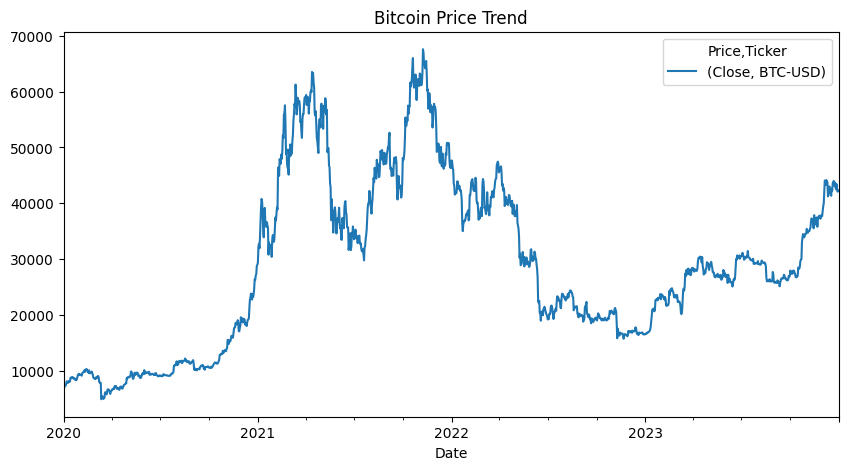

In [9]:
df.plot(figsize=(10,5))
plt.title("Bitcoin Price Trend")
plt.show()

STEP 4: NORMALIZE DATA

In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df)

STEP 5: CREATE TIME SERIES DATA

In [19]:
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 100
X, y = create_dataset(scaled_data, time_step)

X = X.reshape(X.shape[0], X.shape[1], 1)

STEP 6: BUILD LSTM MODEL

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


STEP 7: TRAIN MODEL

In [21]:
model.fit(X, y, epochs=20, batch_size=64)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0458
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0052
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0027
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 0.0023
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0022
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0021
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0020
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0018
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0018
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0017
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0016
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0015
Epoch 13/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0014
Epoch 14/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0014
Epoch 15/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0015
Epoc

STEP 8: PREDICT

In [22]:
predictions = model.predict(X)

predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y.reshape(-1,1))

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


STEP 9: CHECK ACCURACY

In [24]:
def directional_accuracy(actual, predicted):
    correct = 0
    for i in range(1, len(actual)):
        if (actual[i] - actual[i-1]) * (predicted[i] - predicted[i-1]) > 0:
            correct += 1
    return correct / (len(actual)-1)

accuracy = directional_accuracy(actual, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.48270787343635024


STEP 10: PLOT RESULTS

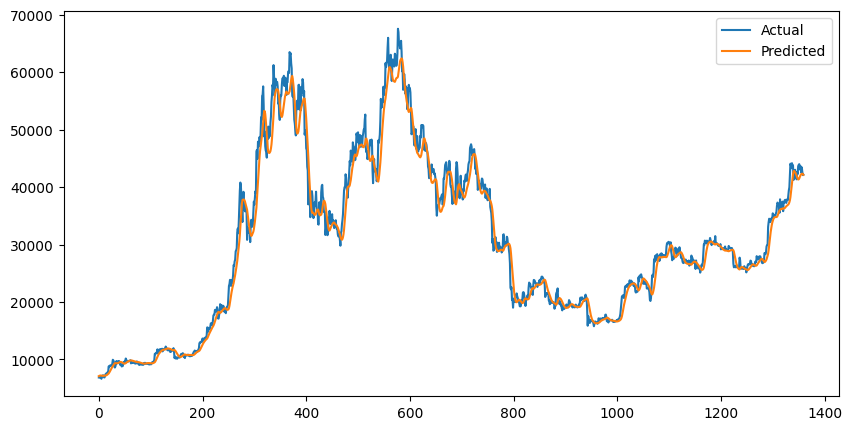

In [25]:
plt.figure(figsize=(10,5))
plt.plot(actual, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.show()

# PART 2: TRADING BOT

STEP 11: CREATE MOVING AVERAGES

In [26]:
df['Short_MA'] = df['Close'].rolling(window=10).mean()
df['Long_MA'] = df['Close'].rolling(window=50).mean()

STEP 12: IMPLEMENT BOT LOGIC

In [29]:
balance = 10000
btc = 0

stop_loss = 0.95
take_profit = 1.05

buy_price = 0

for i in range(50, len(df)):
    price = df['Close'].iloc[i].item()

    # BUY
    if df['Short_MA'].iloc[i].item() > df['Long_MA'].iloc[i].item() and btc == 0:
        btc = balance / price
        buy_price = price
        balance = 0
        print("BUY at", price)

    # SELL
    elif btc > 0:

        if price < buy_price * stop_loss:
            balance = btc * price
            btc = 0
            print("STOP LOSS SELL at", price)

        elif price > buy_price * take_profit:
            balance = btc * price
            btc = 0
            print("TAKE PROFIT SELL at", price)

        elif df['Short_MA'].iloc[i].item() < df['Long_MA'].iloc[i].item():
            balance = btc * price
            btc = 0
            print("TREND SELL at", price)

BUY at 9608.4755859375
STOP LOSS SELL at 8820.5224609375
BUY at 8784.494140625
TREND SELL at 8562.4541015625
BUY at 7096.1845703125
TAKE PROFIT SELL at 7550.90087890625
BUY at 7569.93603515625
TAKE PROFIT SELL at 8801.0380859375
BUY at 8658.5537109375
TAKE PROFIT SELL at 9268.76171875
BUY at 9951.5185546875
STOP LOSS SELL at 8756.4306640625
BUY at 8601.7958984375
TAKE PROFIT SELL at 9269.9873046875
BUY at 9733.7216796875
STOP LOSS SELL at 9081.76171875
BUY at 9182.5771484375
TAKE PROFIT SELL at 9700.4140625
BUY at 9461.05859375
TAKE PROFIT SELL at 10167.2685546875
BUY at 9529.8037109375
TREND SELL at 9313.6103515625
BUY at 9905.1669921875
TAKE PROFIT SELL at 10990.873046875
BUY at 10912.8232421875
TAKE PROFIT SELL at 11759.5927734375
BUY at 11053.6142578125
TAKE PROFIT SELL at 11747.0224609375
BUY at 11779.7734375
STOP LOSS SELL at 10245.296875
BUY at 10511.8134765625
TREND SELL at 10280.3515625
BUY at 11555.36328125
TAKE PROFIT SELL at 12823.689453125
BUY at 12965.8916015625
TAKE PROF

STEP 13: FINAL BALANCE

In [30]:
if btc > 0:
    balance = btc * df['Close'].iloc[-1]

print("Final Balance:", balance)

Final Balance: Ticker
BTC-USD    44164.554778
Name: 2023-12-31 00:00:00, dtype: float64


ARBITRAGE (Simple Demo)

In [31]:
price_binance = 60000
price_coinbase = 60200

if price_coinbase - price_binance > 100:
    print("Arbitrage Opportunity Found")

Arbitrage Opportunity Found
